# Predictive Workforce Planning Using HR Recruitment Analytics
## Step 3: Forecasting Model

**Objective:** Use historical hiring data and attrition rates to forecast 
future hiring needs by department for 2019–2021.

**Approach:** Two complementary models are used:
- **Model 1 — Linear Regression:** Projects overall hiring trend based on historical annual hire counts
- **Model 2 — Attrition-Based Model:** Estimates replacement hires per department using current headcount and attrition rates

**Input:** `../data/processed/HRDataset_Cleaned.csv`

##  Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Libraries imported successfully")

Libraries imported successfully


## Load Cleaned Dataset

In [2]:
df = pd.read_csv('../data/processed/HRDataset_Cleaned.csv')

# Re-parse date columns
df['DateofHire']        = pd.to_datetime(df['DateofHire'],        errors='coerce')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Active Employees  : {df['IsActive'].sum()}")
print(f"Terminated        : {(df['IsActive'] == 0).sum()}")
print(f"Hire Year Range   : {df['HireYear'].min()} – {df['HireYear'].max()}")

Dataset loaded: 311 rows × 41 columns
Active Employees  : 207
Terminated        : 104
Hire Year Range   : 2006 – 2018


---
## 1. Prepare Annual Hiring Data

Before building any model, we prepare the core time series —
annual hire counts from the dataset.

We use **2011–2016** as the training window because:
- 2006–2010 has very few hires (1–9 per year) — likely incomplete records
- 2017–2018 tails off sharply — data collection may be incomplete for those years
- 2011–2016 represents the most complete and consistent hiring activity

## Prepare Annual Hiring Series

In [3]:
# Overall annual hire counts
annual_hires = df['HireYear'].value_counts().sort_index()

# Training window: 2011–2016 (most reliable data range)
train = annual_hires[(annual_hires.index >= 2011) & (annual_hires.index <= 2016)]

print("Full Annual Hire Counts:")
print(annual_hires.to_string())
print(f"\nTraining Window (2011–2016):")
print(train.to_string())
print(f"\nTotal hires in training window : {train.sum()}")
print(f"Average hires per year         : {train.mean():.1f}")

Full Annual Hire Counts:
HireYear
2006     1
2007     2
2008     3
2009     7
2010     9
2011    83
2012    45
2013    44
2014    60
2015    36
2016    14
2017     6
2018     1

Training Window (2011–2016):
HireYear
2011    83
2012    45
2013    44
2014    60
2015    36
2016    14

Total hires in training window : 282
Average hires per year         : 47.0


---
## 2. Model 1 — Linear Regression on Annual Hiring Trend

Linear Regression fits a straight line through historical hire counts
to project the direction of hiring in future years.

**Formula:** `Predicted Hires = slope × Year + intercept`

A **negative slope** means hiring is declining over time.
A **positive slope** means hiring is growing.

## Fit Linear Regression Model

In [4]:
# Prepare training data
X_train = train.index.values.reshape(-1, 1)   # Years as feature
y_train = train.values                          # Hire counts as target

# Fit model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Model evaluation
y_pred_train = model_lr.predict(X_train)
r2  = r2_score(y_train, y_pred_train)
mae = mean_absolute_error(y_train, y_pred_train)

print("=" * 45)
print("LINEAR REGRESSION MODEL RESULTS")
print("=" * 45)
print(f"  Slope (trend per year) : {model_lr.coef_[0]:.2f}")
print(f"  Intercept              : {model_lr.intercept_:.2f}")
print(f"  R² Score               : {r2:.3f}")
print(f"  MAE                    : {mae:.2f} hires")
print()
print("Interpretation:")
if model_lr.coef_[0] < 0:
    print(f"  Hiring is declining by ~{abs(model_lr.coef_[0]):.1f} hires per year")
else:
    print(f"  Hiring is growing by ~{model_lr.coef_[0]:.1f} hires per year")
print(f"  R²={r2:.3f} means the model explains {r2*100:.1f}% of hiring variance")

LINEAR REGRESSION MODEL RESULTS
  Slope (trend per year) : -10.17
  Intercept              : 20527.17
  R² Score               : 0.674
  MAE                    : 10.97 hires

Interpretation:
  Hiring is declining by ~10.2 hires per year
  R²=0.674 means the model explains 67.4% of hiring variance


## Generate Forecast (2019–2021)

In [5]:
# Forecast years
forecast_years = np.array([2019, 2020, 2021]).reshape(-1, 1)

# Predict and clip negatives to 0 (can't have negative hires)
forecast_lr = np.clip(model_lr.predict(forecast_years), 0, None).round(1)

# Build forecast table
forecast_df = pd.DataFrame({
    'Year'           : [2019, 2020, 2021],
    'Predicted_Hires': forecast_lr,
    'Model'          : 'Linear Regression'
})

print("Linear Regression Forecast:")
print(forecast_df.to_string(index=False))

Linear Regression Forecast:
 Year  Predicted_Hires             Model
 2019              0.0 Linear Regression
 2020              0.0 Linear Regression
 2021              0.0 Linear Regression


## Plot Linear Regression Forecast

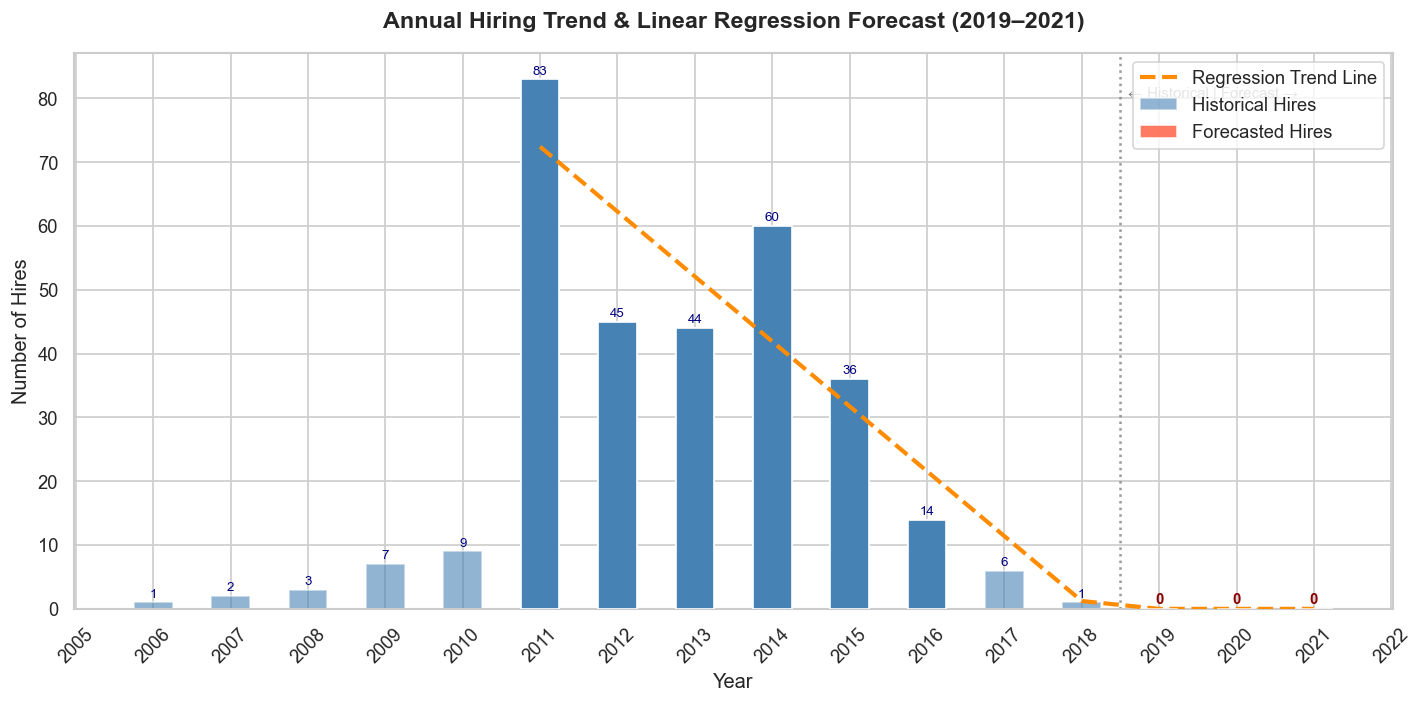

In [6]:
all_years      = annual_hires.index.values
all_hires      = annual_hires.values
train_years    = train.index.values
forecast_yrs   = [2019, 2020, 2021]
forecast_vals  = forecast_lr

# Regression line over full range
line_years = np.arange(2011, 2022).reshape(-1, 1)
line_preds = np.clip(model_lr.predict(line_years), 0, None)

fig, ax = plt.subplots(figsize=(12, 6))

# Historical bars
ax.bar(all_years, all_hires, color='steelblue', alpha=0.6,
       width=0.5, label='Historical Hires', zorder=2)

# Training window highlight
ax.bar(train_years, train.values, color='steelblue', alpha=1.0,
       width=0.5, zorder=3)

# Regression line
ax.plot(line_years, line_preds, color='darkorange', linewidth=2.5,
        linestyle='--', label='Regression Trend Line', zorder=4)

# Forecast bars
ax.bar(forecast_yrs, forecast_vals, color='tomato', alpha=0.85,
       width=0.5, label='Forecasted Hires', zorder=5)

# Value labels
for y, v in zip(all_years, all_hires):
    ax.text(y, v + 0.8, str(int(v)), ha='center', fontsize=8, color='navy')
for y, v in zip(forecast_yrs, forecast_vals):
    ax.text(y, v + 0.8, str(int(v)), ha='center', fontsize=9,
            fontweight='bold', color='darkred')

# Divider line between historical and forecast
ax.axvline(x=2018.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2018.6, ax.get_ylim()[1] * 0.92, '← Historical | Forecast →',
        fontsize=9, color='gray')

ax.set_title('Annual Hiring Trend & Linear Regression Forecast (2019–2021)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Hires')
ax.legend(loc='upper right')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/10_linear_regression_forecast.png', bbox_inches='tight')
plt.show()

---
## 3. Model 2 — Attrition-Based Replacement Forecast

This model estimates **how many new hires each department will need**
to replace employees who are expected to leave, based on their
historical attrition rate.

**Formula:**
> `Predicted Replacement Hires = Active Headcount × Attrition Rate`

This is more actionable than the overall trend model because it
gives **department-level hiring targets**, not just an overall number.

## Build Attrition Model

In [7]:
# Calculate per-department attrition metrics
attrition_model = df.groupby('Department').agg(
    TotalEver    = ('EmpID',    'count'),
    ActiveNow    = ('IsActive', 'sum'),
    Terminated   = ('IsActive', lambda x: (x == 0).sum()),
    AvgTenure    = ('TenureYears', 'mean')
).round(2).reset_index()

attrition_model['AttritionRate']     = (attrition_model['Terminated'] /
                                         attrition_model['TotalEver']).round(3)
attrition_model['AttritionRate_Pct'] = (attrition_model['AttritionRate'] * 100).round(1)

# Predicted annual replacement hires per department
attrition_model['Predicted_Hires_Yr1'] = (
    attrition_model['ActiveNow'] * attrition_model['AttritionRate']
).round(1)

print("=" * 65)
print("ATTRITION-BASED FORECAST MODEL")
print("=" * 65)
print(attrition_model[['Department', 'ActiveNow', 'AttritionRate_Pct',
                         'AvgTenure', 'Predicted_Hires_Yr1']].to_string(index=False))
print(f"\nTotal predicted replacement hires (Year 1): "
      f"{attrition_model['Predicted_Hires_Yr1'].sum():.1f}")

ATTRITION-BASED FORECAST MODEL
          Department  ActiveNow  AttritionRate_Pct  AvgTenure  Predicted_Hires_Yr1
       Admin Offices          7               22.2       4.68                  1.6
    Executive Office          1                0.0       6.50                  0.0
               IT/IS         40               20.0       3.68                  8.0
          Production        126               39.7       4.85                 50.0
               Sales         26               16.1       5.35                  4.2
Software Engineering          7               36.4       5.00                  2.5

Total predicted replacement hires (Year 1): 66.3


## Attrition Forecast Chart

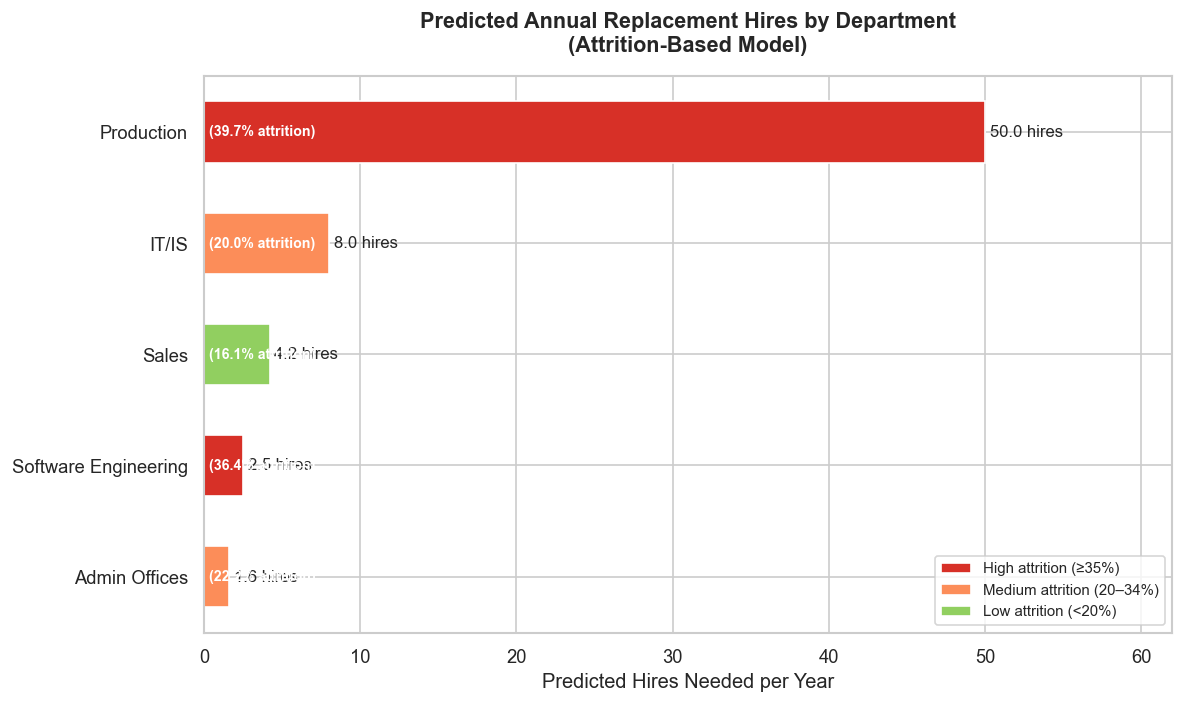

In [8]:
# Exclude Executive Office (only 1 employee, not meaningful)
plot_df = attrition_model[attrition_model['Department'] != 'Executive Office'].copy()
plot_df = plot_df.sort_values('Predicted_Hires_Yr1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d73027' if r >= 35 else '#fc8d59' if r >= 20 else '#91cf60'
          for r in plot_df['AttritionRate_Pct']]
bars = ax.barh(plot_df['Department'], plot_df['Predicted_Hires_Yr1'],
               color=colors, edgecolor='white', height=0.55)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{w:.1f} hires", va='center', fontsize=10)

# Add attrition % annotations
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(0.3, i, f"({row['AttritionRate_Pct']}% attrition)",
            va='center', fontsize=8.5, color='white', fontweight='bold')

ax.set_title('Predicted Annual Replacement Hires by Department\n(Attrition-Based Model)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Hires Needed per Year')
ax.set_xlim(0, plot_df['Predicted_Hires_Yr1'].max() + 12)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d73027', label='High attrition (≥35%)'),
                   Patch(facecolor='#fc8d59', label='Medium attrition (20–34%)'),
                   Patch(facecolor='#91cf60', label='Low attrition (<20%)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/11_attrition_forecast_by_dept.png', bbox_inches='tight')
plt.show()

---
## 4. Department-Level Regression Forecast

Apply Linear Regression to each department individually to see
if any department shows a growing or declining hiring trend.

This helps identify which departments need **proactive hiring** 
(growing trend) vs **retention focus** (declining trend).

## Per-Department Regression

In [10]:
dept_year = df.groupby(['HireYear', 'Department']).size().unstack(fill_value=0)
dept_core = dept_year.loc[2011:2016]

# Only model departments with enough data
top_depts = ['Production', 'IT/IS', 'Sales', 'Software Engineering']
forecast_years_arr = np.array([2019, 2020, 2021]).reshape(-1, 1)

dept_forecast_results = []

print("=" * 65)
print("PER-DEPARTMENT LINEAR REGRESSION RESULTS")
print("=" * 65)

for dept in top_depts:
    Xd = dept_core.index.values.reshape(-1, 1)
    yd = dept_core[dept].values

    md = LinearRegression()
    md.fit(Xd, yd)

    r2d  = r2_score(yd, md.predict(Xd))
    maed = mean_absolute_error(yd, md.predict(Xd))
    preds_d = np.clip(md.predict(forecast_years_arr), 0, None).round(1)

    print(f"\n{dept}")
    print(f"   Slope (trend/yr) : {md.coef_[0]:.2f}")
    print(f"   R² Score         : {r2d:.3f}")
    print(f"   MAE              : {maed:.2f}")
    print(f"   Forecast 2019    : {preds_d[0]:.1f} hires")
    print(f"   Forecast 2020    : {preds_d[1]:.1f} hires")
    print(f"   Forecast 2021    : {preds_d[2]:.1f} hires")

    for yr, pred in zip([2019, 2020, 2021], preds_d):
        dept_forecast_results.append({
            'Department': dept,
            'Year': yr,
            'Predicted_Hires': pred,
            'Slope': round(md.coef_[0], 2),
            'R2': round(r2d, 3)
        })

dept_forecast_df = pd.DataFrame(dept_forecast_results)

PER-DEPARTMENT LINEAR REGRESSION RESULTS

Production
   Slope (trend/yr) : -10.80
   R² Score         : 0.826
   MAE              : 6.80
   Forecast 2019    : 0.0 hires
   Forecast 2020    : 0.0 hires
   Forecast 2021    : 0.0 hires

IT/IS
   Slope (trend/yr) : 2.00
   R² Score         : 0.280
   MAE              : 4.33
   Forecast 2019    : 18.0 hires
   Forecast 2020    : 20.0 hires
   Forecast 2021    : 22.0 hires

Sales
   Slope (trend/yr) : -0.83
   R² Score         : 0.180
   MAE              : 2.19
   Forecast 2019    : 0.3 hires
   Forecast 2020    : 0.0 hires
   Forecast 2021    : 0.0 hires

Software Engineering
   Slope (trend/yr) : -0.77
   R² Score         : 0.812
   MAE              : 0.56
   Forecast 2019    : 0.0 hires
   Forecast 2020    : 0.0 hires
   Forecast 2021    : 0.0 hires


## Department Forecast Chart

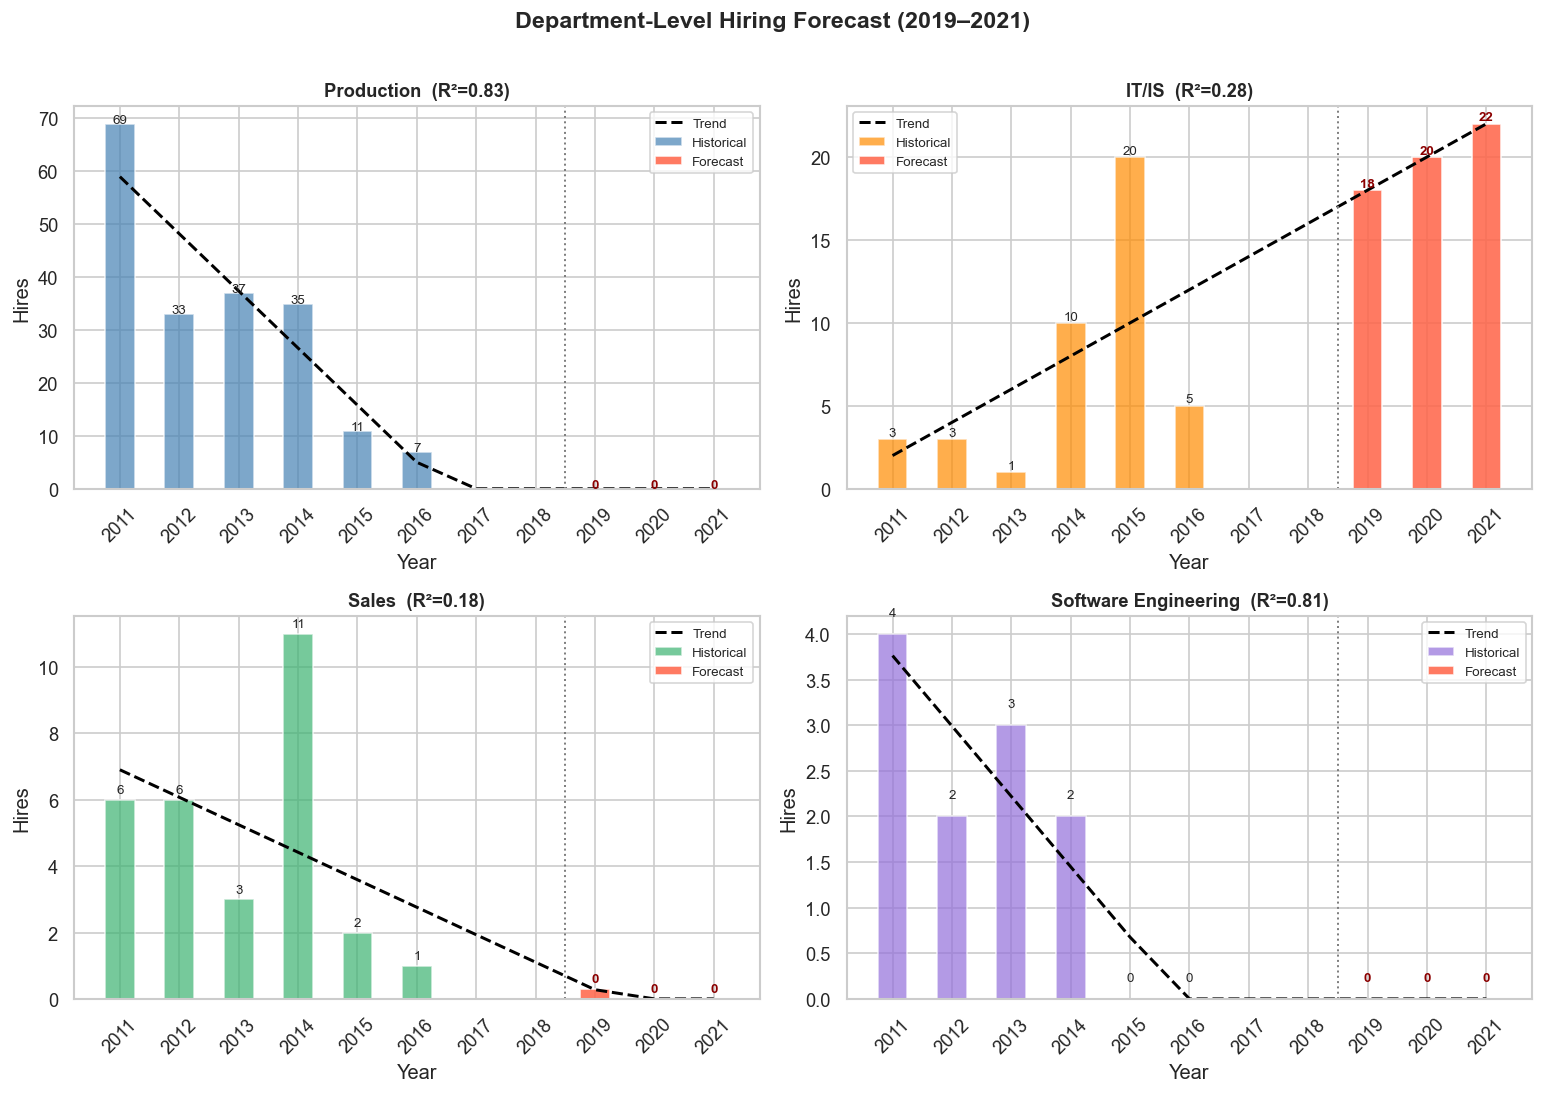

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
palette = ['steelblue', 'darkorange', 'mediumseagreen', 'mediumpurple']

for idx, dept in enumerate(top_depts):
    ax = axes[idx]

    # Historical
    hist = dept_core[dept]
    Xd   = hist.index.values.reshape(-1, 1)
    yd   = hist.values
    md   = LinearRegression().fit(Xd, yd)

    # Trend line
    line_x = np.arange(2011, 2022).reshape(-1, 1)
    line_y = np.clip(md.predict(line_x), 0, None)

    # Forecast
    f_preds = np.clip(md.predict(forecast_years_arr), 0, None).round(1)

    ax.bar(hist.index, hist.values, color=palette[idx],
           alpha=0.7, width=0.5, label='Historical')
    ax.bar([2019, 2020, 2021], f_preds, color='tomato',
           alpha=0.85, width=0.5, label='Forecast')
    ax.plot(line_x, line_y, color='black', linewidth=1.8,
            linestyle='--', label='Trend')
    ax.axvline(x=2018.5, color='gray', linestyle=':', linewidth=1.2)

    # Labels
    for y, v in zip(hist.index, hist.values):
        ax.text(y, v + 0.2, str(int(v)), ha='center', fontsize=8)
    for y, v in zip([2019, 2020, 2021], f_preds):
        ax.text(y, v + 0.2, str(int(v)), ha='center', fontsize=8,
                fontweight='bold', color='darkred')

    r2d = r2_score(yd, md.predict(Xd))
    ax.set_title(f"{dept}  (R²={r2d:.2f})", fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Hires')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.legend(fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Department-Level Hiring Forecast (2019–2021)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/12_dept_regression_forecast.png', bbox_inches='tight')
plt.show()

---
## 5. Combined Forecast Summary Table

Combining both models gives a balanced view:
- **Regression forecast** reflects the historical hiring trend
- **Attrition forecast** reflects replacement need based on current headcount

The **higher of the two** values should be used as the recommended 
hiring target — it covers both trend and replacement demand.

In [12]:
# Attrition model values
attrition_vals = attrition_model.set_index('Department')['Predicted_Hires_Yr1']

# Regression model values for 2019
reg_vals = dept_forecast_df[dept_forecast_df['Year'] == 2019].set_index('Department')['Predicted_Hires']

# Combine
summary = pd.DataFrame({
    'Active_Headcount'    : attrition_model.set_index('Department')['ActiveNow'],
    'Attrition_Rate_%'    : attrition_model.set_index('Department')['AttritionRate_Pct'],
    'Attrition_Forecast'  : attrition_vals,
    'Regression_Forecast' : reg_vals
}).fillna(0)

summary['Recommended_Hires'] = summary[['Attrition_Forecast',
                                          'Regression_Forecast']].max(axis=1).round(1)
summary['Priority'] = summary['Attrition_Rate_%'].apply(
    lambda x: 'High' if x >= 35 else ('Medium' if x >= 20 else 'Low')
)

print("=" * 75)
print("COMBINED FORECAST SUMMARY — RECOMMENDED HIRES (NEXT YEAR)")
print("=" * 75)
print(summary[['Active_Headcount', 'Attrition_Rate_%',
               'Attrition_Forecast', 'Regression_Forecast',
               'Recommended_Hires', 'Priority']].to_string())
print(f"\nTotal Recommended Hires (Organisation-wide): "
      f"{summary['Recommended_Hires'].sum():.0f}")

COMBINED FORECAST SUMMARY — RECOMMENDED HIRES (NEXT YEAR)
                      Active_Headcount  Attrition_Rate_%  Attrition_Forecast  Regression_Forecast  Recommended_Hires Priority
Department                                                                                                                   
Admin Offices                        7              22.2                 1.6                  0.0                1.6   Medium
Executive Office                     1               0.0                 0.0                  0.0                0.0      Low
IT/IS                               40              20.0                 8.0                 18.0               18.0   Medium
Production                         126              39.7                50.0                  0.0               50.0     High
Sales                               26              16.1                 4.2                  0.3                4.2      Low
Software Engineering                 7              36.4    

## Combined Forecast Bar Chart

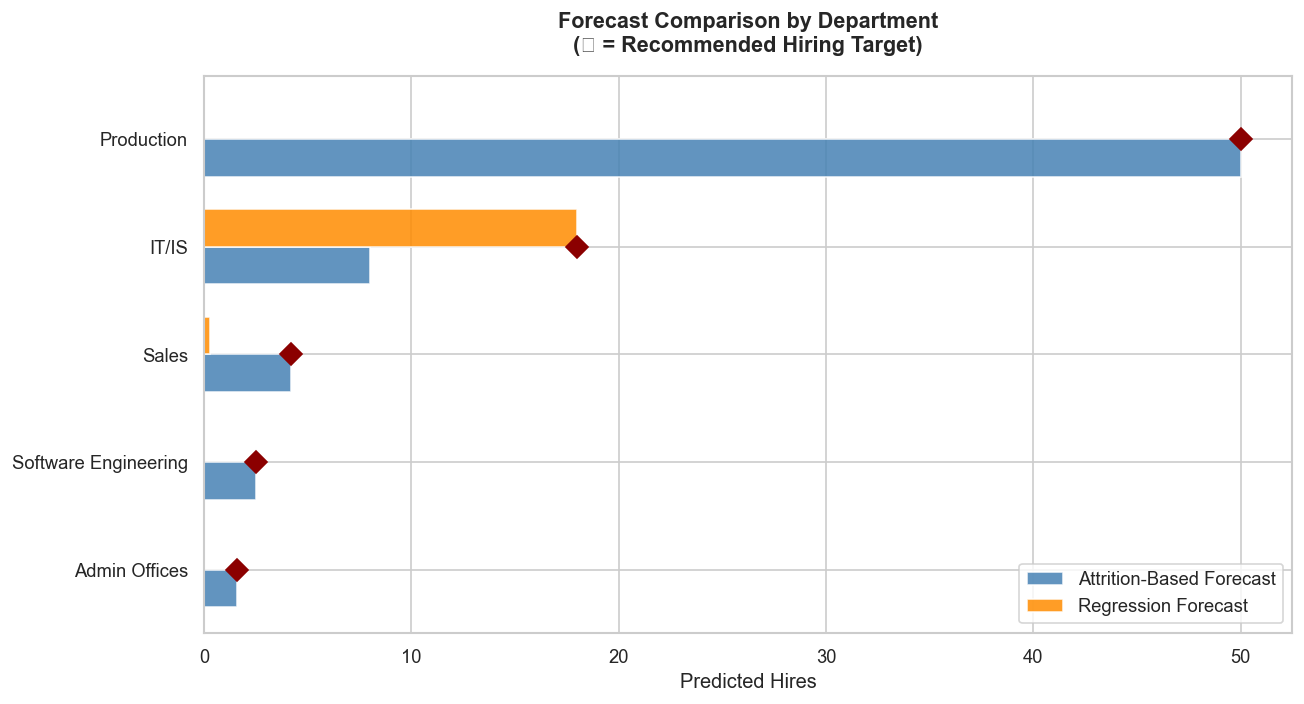

In [13]:
plot_summary = summary[summary.index != 'Executive Office'].copy()
plot_summary = plot_summary.sort_values('Recommended_Hires', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(plot_summary))
width = 0.35

bars1 = ax.barh(x - width/2, plot_summary['Attrition_Forecast'],
                width, label='Attrition-Based Forecast', color='steelblue', alpha=0.85)
bars2 = ax.barh(x + width/2, plot_summary['Regression_Forecast'],
                width, label='Regression Forecast', color='darkorange', alpha=0.85)

# Recommended hires line markers
for i, (_, row) in enumerate(plot_summary.iterrows()):
    ax.plot(row['Recommended_Hires'], i, marker='D',
            color='darkred', markersize=9, zorder=5)

ax.set_yticks(x)
ax.set_yticklabels(plot_summary.index)
ax.set_xlabel('Predicted Hires')
ax.set_title('Forecast Comparison by Department\n(◆ = Recommended Hiring Target)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/13_combined_forecast_comparison.png', bbox_inches='tight')
plt.show()

---
## 6. Model Evaluation

How well do our models perform against actual known data?
We compare model predictions against real 2016 hire counts
(the last year in training data) as a sanity check.

In [14]:
# Compare 2016 predictions vs actuals (last known year)
actual_2016 = dept_core.loc[2016]
X_2016 = np.array([[2016]])

print("=" * 55)
print("MODEL EVALUATION — 2016 ACTUALS vs PREDICTIONS")
print("=" * 55)
print(f"{'Department':<22} {'Actual':>8} {'Predicted':>10} {'Error':>8}")
print("-" * 55)

for dept in top_depts:
    Xd = dept_core.index.values.reshape(-1, 1)
    yd = dept_core[dept].values
    md = LinearRegression().fit(Xd, yd)
    pred_2016 = max(0, md.predict(X_2016)[0])
    actual     = actual_2016[dept]
    error      = abs(actual - pred_2016)
    print(f"{dept:<22} {actual:>8.0f} {pred_2016:>10.1f} {error:>8.1f}")

# Overall model R2 summary
print(f"\nOverall Linear Regression R² : {r2:.3f}")
print(f"Overall MAE                  : {mae:.2f} hires")
print("\nNote: Small dataset (6 years) limits model precision.")
print("Attrition-based model is more reliable for dept-level planning.")

MODEL EVALUATION — 2016 ACTUALS vs PREDICTIONS
Department               Actual  Predicted    Error
-------------------------------------------------------
Production                    7        5.0      2.0
IT/IS                         5       12.0      7.0
Sales                         1        2.8      1.8
Software Engineering          0        0.0      0.0

Overall Linear Regression R² : 0.674
Overall MAE                  : 10.97 hires

Note: Small dataset (6 years) limits model precision.
Attrition-based model is more reliable for dept-level planning.


## Final Forecasting Summary Print

In [15]:
print("=" * 60)
print("FORECASTING MODEL — FINAL SUMMARY")
print("=" * 60)

print("\n Model 1 — Linear Regression (Overall Trend)")
print(f"   Training period : 2011–2016")
print(f"   R² Score        : {r2:.3f}")
print(f"   Trend           : Declining (~10 fewer hires/year)")
print(f"   Forecast 2019   : {int(np.clip(model_lr.predict([[2019]])[0], 0, None))} hires")

print("\n Model 2 — Attrition-Based (Department Level)")
print(f"   Total org-wide replacement hires needed : ~{attrition_model['Predicted_Hires_Yr1'].sum():.0f}/year")
for _, row in attrition_model[attrition_model['Department'] != 'Executive Office'].iterrows():
    print(f"   {row['Department']:<22}: {row['Predicted_Hires_Yr1']:>5.1f} hires  "
          f"({row['AttritionRate_Pct']}% attrition)")

print("\n Recommended Hiring Priorities")
high = summary[summary['Priority'] == 'High'].index.tolist()
med  = summary[summary['Priority'] == 'Medium'].index.tolist()
low  = summary[summary['Priority'] == 'Low'].index.tolist()
print(f"   High Priority  : {', '.join(high)}")
print(f"   Medium Priority: {', '.join(med)}")
print(f"   Low Priority   : {', '.join(low)}")

FORECASTING MODEL — FINAL SUMMARY

 Model 1 — Linear Regression (Overall Trend)
   Training period : 2011–2016
   R² Score        : 0.674
   Trend           : Declining (~10 fewer hires/year)
   Forecast 2019   : 0 hires

 Model 2 — Attrition-Based (Department Level)
   Total org-wide replacement hires needed : ~66/year
   Admin Offices         :   1.6 hires  (22.2% attrition)
   IT/IS                 :   8.0 hires  (20.0% attrition)
   Production            :  50.0 hires  (39.7% attrition)
   Sales                 :   4.2 hires  (16.1% attrition)
   Software Engineering  :   2.5 hires  (36.4% attrition)

 Recommended Hiring Priorities
   High Priority  : Production, Software Engineering
   Medium Priority: Admin Offices, IT/IS
   Low Priority   : Executive Office, Sales


---
## Step 3 Completed — Forecasting Summary

| Model | Scope | Best Used For |
|---|---|---|
| Linear Regression | Organisation-wide trend | Overall budget planning |
| Attrition-Based | Per department | Department-level hiring targets |

### Charts Saved
| Chart | File |
|---|---|
| Overall regression forecast | `10_linear_regression_forecast.png` |
| Attrition forecast by dept | `11_attrition_forecast_by_dept.png` |
| Per-dept regression subplots | `12_dept_regression_forecast.png` |
| Combined model comparison | `13_combined_forecast_comparison.png` |

### Key Takeaways
| Finding | Value |
|---|---|
| Organisation-wide replacement hires needed/year | ~66 |
| Highest priority department | Production (39.7% attrition, 50 hires/yr) |
| Fastest churn department | Production (avg 2.5 yr churn cycle) |
| Growing hiring trend | IT/IS (positive regression slope) |
| Most stable department | Sales (16.1% attrition) |

**Next Step → Notebook 04: Final Report**